# Notebook 1 — Temporal response classes

**Summer course: data-analysis pitfalls**

You are handed a population recording: the activity of many neurons over the
course of a 5-second trial, stored as a `neurons x time` matrix. A colleague
has already run the standard analysis below and attached a conclusion to the
final figure.

> ### The claim
> *"The population contains three distinct functional classes of neurons —*
> ***early**, **middle**, and **late** responders — each with its own reliable*
> *temporal response profile."*

**The claim is false.** Your job is to figure out *why*. Run the notebook,
look at the figure, and then work out what is really going on in these data.

The goal is to build the instinct to interrogate a result like this yourself.
If you get stuck, `hints.md` has some guiding questions and
`notebook1_solution.ipynb` has the full answer — but get as far as you can on
your own first.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Plotting style ---
plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

rng = np.random.default_rng(0)  # for cosmetic row shuffling only

HEAT_CMAP = 'inferno'           # perceptually-uniform colormap for heatmaps

def cluster_palette(n):
    """n distinct qualitative colors, one per cluster."""
    return plt.cm.tab10(np.arange(n) % 10)

def cluster_label(c, k):
    """Human-readable cluster name. For k=3 use early/middle/late."""
    if k == 3:
        return f'cluster {c} ({["early", "middle", "late"][c]})'
    return f'cluster {c}'


In [2]:
# Load the dataset: a (neurons x time) matrix of activity.
d = np.load('data/activity.npz')
activity = d['activity']      # shape (n_neurons, n_time)
time = d['time']              # seconds
n_neurons, n_time = activity.shape
print(f'{n_neurons} neurons x {n_time} time bins '
      f'({time[0]:.2f}-{time[-1]:.2f} s)')


300 neurons x 100 time bins (0.00-4.95 s)


## The raw data

Each row is a neuron, each column a time bin. This is the matrix everything
below is computed from.


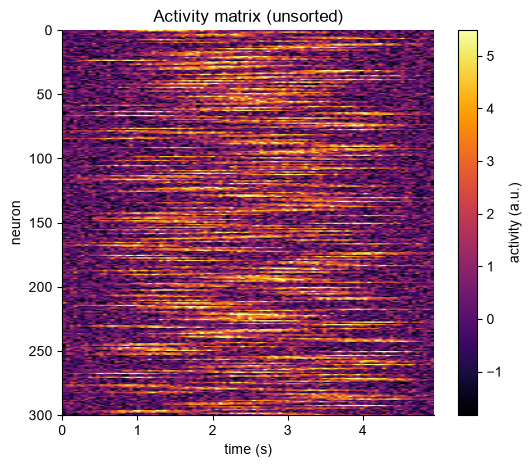

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(activity, aspect='auto', cmap=HEAT_CMAP,
               vmin=np.percentile(activity, 2), vmax=np.percentile(activity, 99),
               extent=[time[0], time[-1], n_neurons, 0])
ax.set_xlabel('time (s)'); ax.set_ylabel('neuron')
ax.set_title('Activity matrix (unsorted)')
plt.colorbar(im, ax=ax, label='activity (a.u.)')
plt.show()


## Step 1 — How many clusters?

Rather than pick a number by hand, we use **silhouette analysis** — a standard,
principled way to choose the number of clusters — scanning `k = 2 ... 8` and
keeping the k with the best score.


In [4]:
from sklearn.metrics import silhouette_score

# For each candidate number of clusters k, run k-means and score the result
# with the silhouette (how much tighter points sit to their own cluster than to
# the nearest other cluster; higher = more clustered). Keep the k that scores best.
candidate_ks = range(2, 9)
sil = {kk: silhouette_score(activity,
        KMeans(n_clusters=kk, n_init=10, random_state=0).fit_predict(activity))
       for kk in candidate_ks}
best_k = max(sil, key=sil.get)          # the k with the highest silhouette score
print(f'Silhouette analysis selects k = {best_k} clusters.')


Silhouette analysis selects k = 3 clusters.


## Step 2 — Cluster the neurons

Silhouette analysis picked three clusters, so we treat each neuron's time
course as a feature vector and run k-means with `k = 3`.


In [5]:
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=0)
labels = km.fit_predict(activity)       # assign each neuron to one of k clusters

# Relabel the clusters so 0/1/2 run early -> middle -> late in time. This is
# purely cosmetic (a consistent naming); it does not change the clustering.
# For each cluster, take the mean trace and find the time bin of its peak:
peak_of_mean = np.array([activity[labels == c].mean(0).argmax() for c in range(k)])
order = np.argsort(peak_of_mean)        # cluster indices sorted by peak time
relabel = np.zeros(k, dtype=int)
relabel[order] = np.arange(k)           # earliest-peaking cluster -> label 0, etc.
labels = relabel[labels]

for c in range(k):
    print(f'cluster {c}: {(labels == c).sum()} neurons')


cluster 0: 112 neurons
cluster 1: 107 neurons
cluster 2: 81 neurons


## Step 3 — Visualize the clusters

Two views:
1. **Heatmaps** of the neurons in each cluster (rows in arbitrary order).
2. **Mean response** of each cluster (mean +/- SEM across neurons).


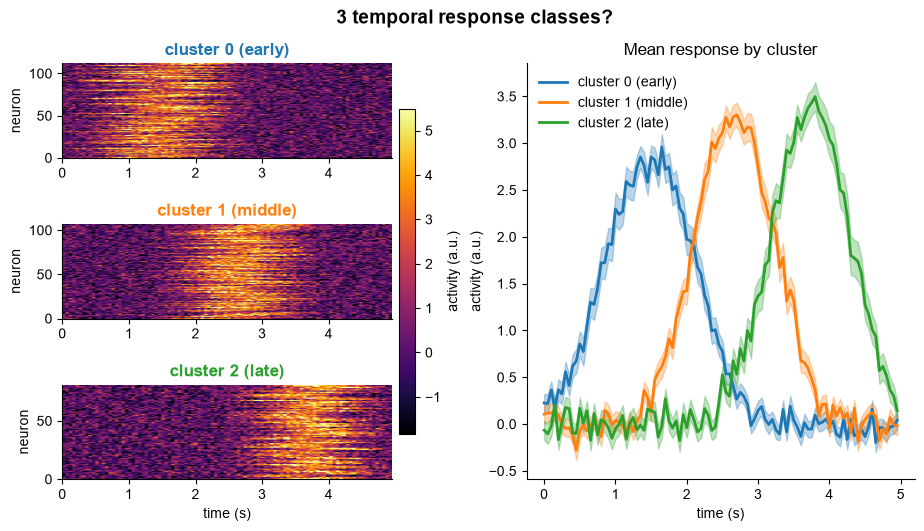

In [6]:
colors = cluster_palette(k)

fig = plt.figure(figsize=(11, 1.6 * k + 0.6))
gs = fig.add_gridspec(k, 2, width_ratios=[1, 1.1], hspace=0.7, wspace=0.3)

# Shared color scale across all heatmaps.
vmin = np.percentile(activity, 2)
vmax = np.percentile(activity, 99)

# --- Left column: one heatmap per cluster (rows shuffled within cluster) ---
heat_axes = []
for c in range(k):
    ax = fig.add_subplot(gs[c, 0])
    idx = rng.permutation(np.where(labels == c)[0])   # arbitrary row order
    im = ax.imshow(activity[idx], aspect='auto', cmap=HEAT_CMAP,
                   vmin=vmin, vmax=vmax,
                   extent=[time[0], time[-1], 0, len(idx)])
    ax.set_title(cluster_label(c, k), color=colors[c], fontweight='bold')
    ax.set_ylabel('neuron')
    if c == k - 1:
        ax.set_xlabel('time (s)')
    heat_axes.append(ax)

cbar = fig.colorbar(im, ax=heat_axes, fraction=0.046, pad=0.02)
cbar.set_label('activity (a.u.)')

# --- Right column: mean +/- SEM trace per cluster ---
ax = fig.add_subplot(gs[:, 1])
for c in range(k):
    m = activity[labels == c].mean(0)   # average trace across neurons in cluster c
    # standard error of that mean at each time point (std across neurons / sqrt(n))
    sem = activity[labels == c].std(0) / np.sqrt((labels == c).sum())
    ax.plot(time, m, color=colors[c], lw=2, label=cluster_label(c, k))
    ax.fill_between(time, m - sem, m + sem, color=colors[c], alpha=0.3)
ax.set_xlabel('time (s)')
ax.set_ylabel('activity (a.u.)')
ax.set_title('Mean response by cluster')
ax.legend(frameon=False)

fig.suptitle(f'{k} temporal response classes?', fontsize=14, fontweight='bold')
plt.show()
